### Importando a biblioteca Pandas e Matplotlib

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

### Lendo o arquivo CSV e ajustando linha errada 

In [2]:
dados= pd.read_csv('googleplaystore.csv')

error_row= dados[dados['App']== 'Life Made WI-Fi Touchscreen Photo Frame']

row_index = error_row.index[0]

row_index = error_row.index[0]  

dados.at[row_index, 'App'] = 'Life Made WI-Fi Touchscreen Photo Frame'
dados.at[row_index, 'Category'] = ''  
dados.at[row_index, 'Rating'] = 1.9
dados.at[row_index, 'Reviews'] = 19.0
dados.at[row_index, 'Size'] = '3.0M'
dados.at[row_index, 'Installs'] = '1,000+'
dados.at[row_index, 'Type'] = 'Free'
dados.at[row_index, 'Price'] = 0
dados.at[row_index, 'Content Rating'] = 'Everyone'
dados.at[row_index, 'Genres'] = ''
dados.at[row_index, 'Last Updated'] = 'February 11, 2018'
dados.at[row_index, 'Current Ver'] = '1.0.19'
dados.at[row_index, 'Android Ver'] = '4.0 and up'

dados.to_csv('googleplaystore.csv', index=False)

### 1 - Removendo apps duplicados de cada categoria, mantendo somente o com maior número de reviews em cada categoria

In [3]:
dados_ordened= dados.sort_values('Reviews', ascending=False) 

df= (dados_ordened.drop_duplicates(subset=['App','Category'], keep='first'))

df.to_csv('googleplaystore.csv', index=False)
 
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Facebook,SOCIAL,4.1,78158306.0,Varies with device,"1,000,000,000+",Free,0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,Instagram,SOCIAL,4.5,66577446.0,Varies with device,"1,000,000,000+",Free,0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578.0,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,Clash of Clans,GAME,4.6,44893888.0,98M,"100,000,000+",Free,0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9349,Team CF,LIFESTYLE,NaN,0.0,3.0M,100+,Free,0,Everyone,Lifestyle,"June 7, 2018",3.9.9.2,2.3 and up
9350,CE-STRONG,FAMILY,NaN,0.0,16M,100+,Free,0,Everyone,Education,"June 17, 2016",1.0.4,4.0 and up
9351,i miss you quotes and photos,DATING,NaN,0.0,5.0M,100+,Free,0,Everyone,Dating,"July 22, 2018",1.0.7,4.0 and up
9352,EW Gate,BUSINESS,NaN,0.0,12M,50+,Free,0,Everyone,Business,"April 16, 2018",3.07,4.0 and up


### 2 - Gráfico de barras dos 5 apps com maior número de instalação

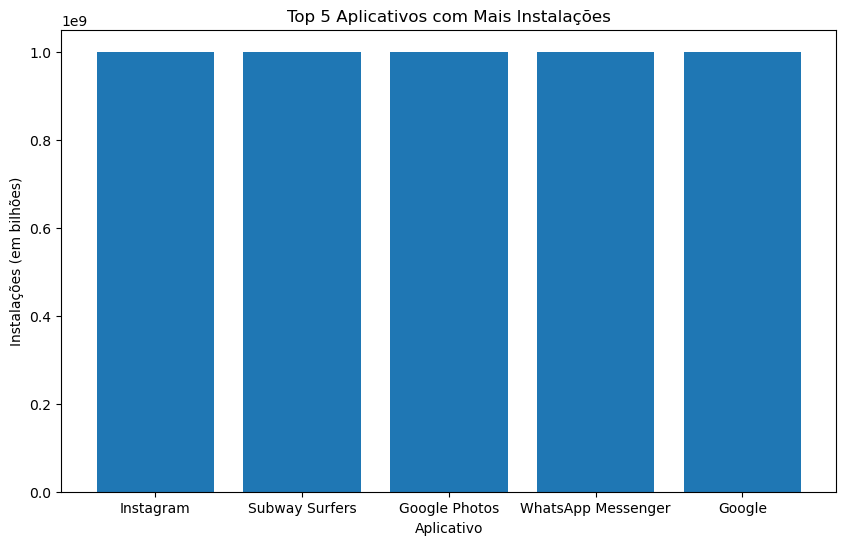

In [4]:
n_install= (df.drop_duplicates(subset='App')).copy()

# Remove caracteres não numéricos da coluna 'Installs'
n_install['Installs'] = (n_install['Installs'].str.replace(r'[^\d]', '', regex=True))

# Converte a coluna 'Installs' para numérico
n_install['Installs'] = pd.to_numeric(n_install['Installs'], errors='coerce')

# Agrupar pelo aplicativo ('App') 
top_install = n_install.sort_values(by=['Installs', 'Rating', 'Reviews'], ascending=[False, False, False]).head(5) 

#Criar o gráfico de barras
plt.figure(figsize=(10, 6))  # Ajustar o tamanho do gráfico
plt.bar(top_install['App'], top_install['Installs'])

plt.title('Top 5 Aplicativos com Mais Instalações')
plt.xlabel('Aplicativo')
plt.ylabel('Instalações (em bilhões)')

plt.show()

### 3 - Gráfico de pizza das categorias de app existentes como é pedido

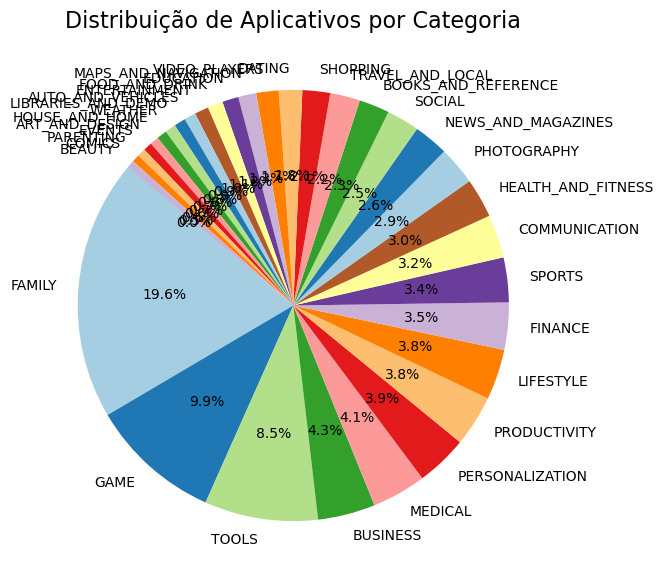

In [5]:
# Agrupando por categoria e contando a quantidade de apps por categoria
category= df.groupby('Category', as_index=False)['App'].count()

top_categories = category.sort_values('App', ascending=False)

category_pie = top_categories

# Cria o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    category_pie['App'],
    labels=category_pie['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors  # Paleta de cores
)

# Adiciona título
plt.title('Distribuição de Aplicativos por Categoria', fontsize=16)

# Exibi o gráfico
plt.show()

### 3.1 - Sugestão de gráfico otimizado para melhor vizualização dos dados

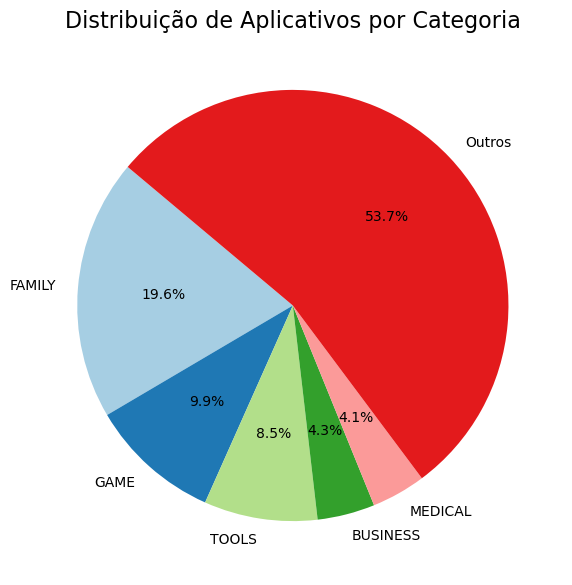

In [6]:
top_categories = category.sort_values('App', ascending=False).head(5)
others = pd.DataFrame({
    'Category': ['Outros'],
    'App': [category['App'].sum() - top_categories['App'].sum()]
})
category_pie = pd.concat([top_categories, others], ignore_index=True)

# Cria o gráfico de pizza
plt.figure(figsize=(10, 7))
plt.pie(
    category_pie['App'],
    labels=category_pie['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors  # Paleta de cores
)

# Adiciona título
plt.title('Distribuição de Aplicativos por Categoria', fontsize=16)

# Exibi o gráfico
plt.show()

### 3.2 - Segunda sugestão: gráfico de barras


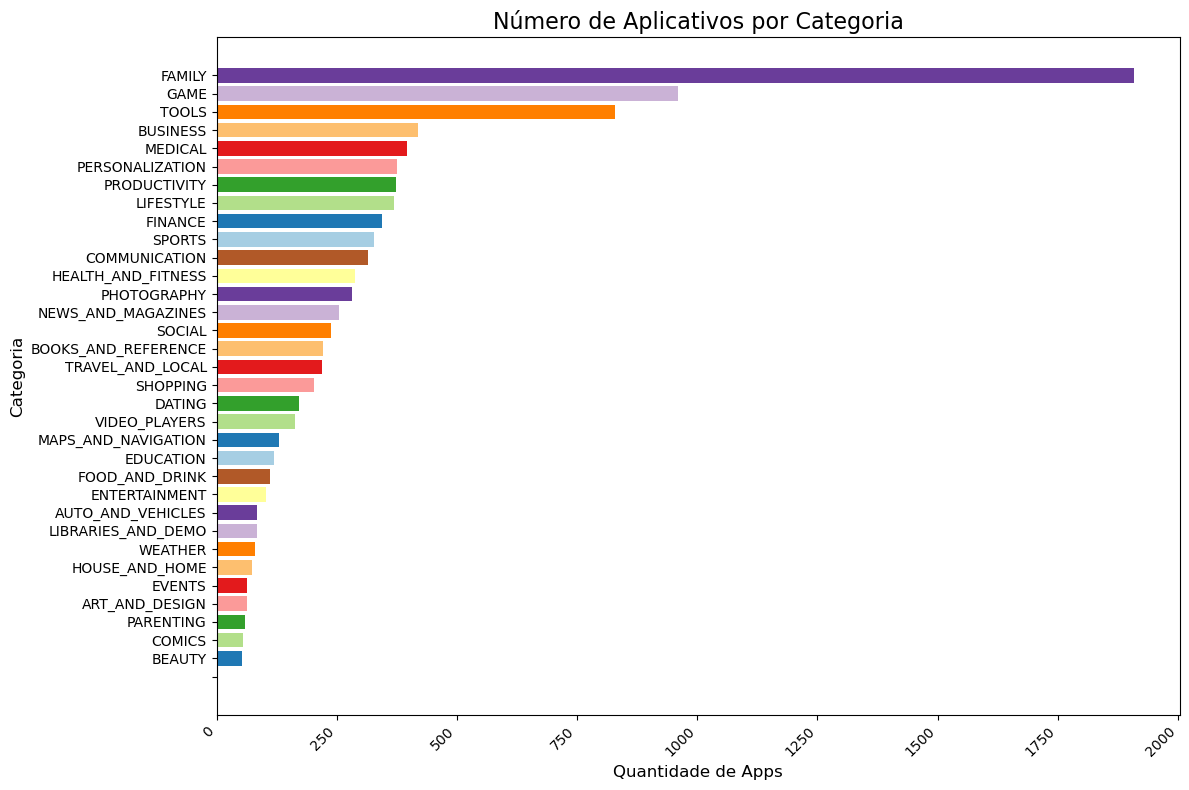

In [7]:
# Agrupando por categoria e contando a quantidade de apps por categoria
category = df.groupby('Category', as_index=False)['App'].count()

# Ordenando as categorias pelo número de apps
top_categories = category.sort_values('App')

# Criando o gráfico de barras
plt.figure(figsize=(12, 8))
plt.barh(top_categories['Category'], top_categories['App'], color=plt.cm.Paired.colors)

# Adicionando título e rótulos
plt.title('Número de Aplicativos por Categoria', fontsize=16)
plt.xlabel('Quantidade de Apps', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Rotação dos rótulos no eixo X para melhor visualização
plt.xticks(rotation=45, ha='right')

# Exibindo o gráfico
plt.tight_layout()
plt.show()

### 4 - Fazendo busca pelo app mais caro

In [8]:
price= df[['App', 'Price']].copy() 

# Remove o caractere de dólar ('$') e converte 'Price' para numérico
price['Price'] = price['Price'].str.replace(r'[$]', '', regex=True)
price['Price'] = pd.to_numeric(price['Price'], errors='coerce')

# Ordena pelos preços mais altos
top_price = (price.sort_values('Price', ascending=False).head(1))

top_price

,App,Price
5725,I'm Rich - Trump Edition,400.0


### 5 - Quantidade de apps classificados como 'Mature 17+'

In [9]:
# Fazendo a soma de todos os apps que contém essa exata string em "Content Rating"
mature= df['Content Rating'].str.contains('Mature 17+', na=False).sum()

print(f'Essa é a quantidade total de apps classificados como "Mature 17+": {mature}')

Essa é a quantidade total de apps classificados como "Mature 17+": 393


### 6 - Top 10 apps por número de reviews com seus respectivos números de reviews

In [10]:
review= df.copy()

# Converte a coluna 'Reviews' para numérico
review['Reviews'] = pd.to_numeric(review['Reviews'], errors='coerce')

# Agrupa por 'App' e pega o maior número de 'Reviews' para cada aplicativo
top10 = (review.groupby('App', as_index=False)['Reviews'].max()).sort_values('Reviews', ascending=False).head(10)

top10

,App,Reviews
4328,Facebook,78158306.0
9042,WhatsApp Messenger,69119316.0
5399,Instagram,66577446.0
6166,Messenger – Text and Video Chat for Free,56646578.0
2564,Clash of Clans,44893888.0
2573,Clean Master- Space Cleaner & Antivirus,42916526.0
8080,Subway Surfers,27725352.0
9226,YouTube,25655305.0
7722,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999.0
2561,Clash Royale,23136735.0


### 7.1 - Top 3 categorias melhor avaliadas

In [11]:
category= df.groupby('Category', as_index=False)['Rating'].mean().sort_values('Rating', ascending=False).head(3)

category

,Category,Rating
11,EVENTS,4.435556
9,EDUCATION,4.364407
1,ART_AND_DESIGN,4.357377


### 7.2 - Média de avaliação dos aplicativos

In [13]:
mean= df['Rating'].mean()

print(f'A média de avaliação dos apps é: {mean:.2f}')

A média de avaliação dos apps é: 4.17


### 8.1 - Gráfico de linhas das 3 categorias melhor avaliadas


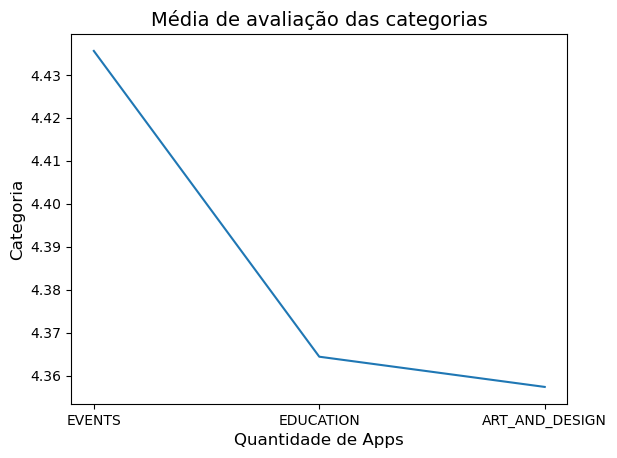

In [14]:

df_limited = df.groupby('Category', as_index=False)['Rating'].mean().sort_values('Rating', ascending=False).head(3)
plt.plot(df_limited['Category'], df_limited['Rating'])

# Configura os rótulos e título
plt.title('Média de avaliação das categorias', fontsize=14)
plt.xlabel('Quantidade de Apps', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

plt.show()

### 8.2 - Gráfico de dispersão das 10 piores médias das caregorias

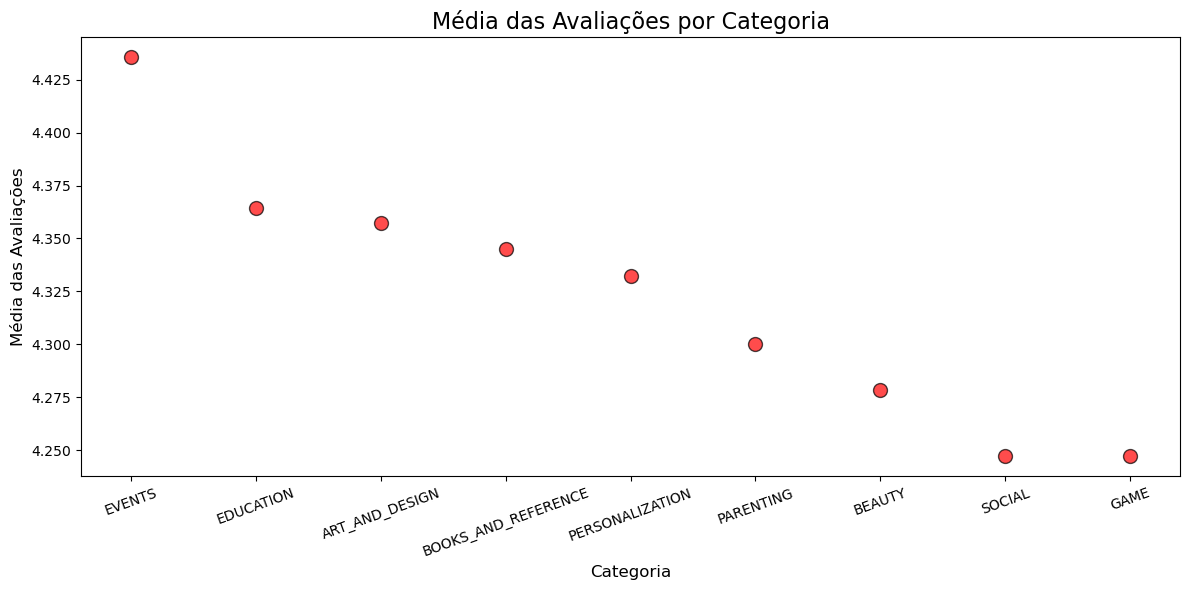

In [15]:
# Agrupando por categoria e calculando a média das avaliações
category = df.groupby('Category', as_index=False)['Rating'].mean().sort_values('Rating', ascending=False).head(10)

# Excluindo a última categoria, pois é vazia, da linha defeituosa
category = category.iloc[:-1]

# Criando o gráfico de dispersão
plt.figure(figsize=(12, 6))
plt.scatter(category['Category'], category['Rating'], color='red', s=100, edgecolor='black', alpha=0.7)

# Adicionando título e rótulos
plt.title('Média das Avaliações por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Média das Avaliações', fontsize=12)

# Ajustando o layout para melhorar a visualização
plt.xticks(rotation=20)  # Rotacionando as categorias para melhor visualização
plt.tight_layout()

# Exibindo o gráfico
plt.show()
